In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # PCA의 1단계(데이터 표준화) 를 자동으로 처리해주는 도구
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

과제 1: PCA 실습
Iris 데이터를 2D로 축소 → 설명된 분산 확인 및 시각화

In [2]:
# 데이터 로드
iris = load_iris()
X = iris.data

In [3]:
# 표준화 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
#  PCA (2차원으로 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [48]:
# 설명된 분산
print(f"설명된 분산:") 
for i, var in enumerate(pca.explained_variance_ratio_): 
    print(f"PC{i+1}: {var*100:.2f}%") 
print(f"총{sum(pca.explained_variance_ratio_)*100:.2f}% 보존")

설명된 분산:
PC1: 72.96%
PC2: 22.85%
총95.81% 보존


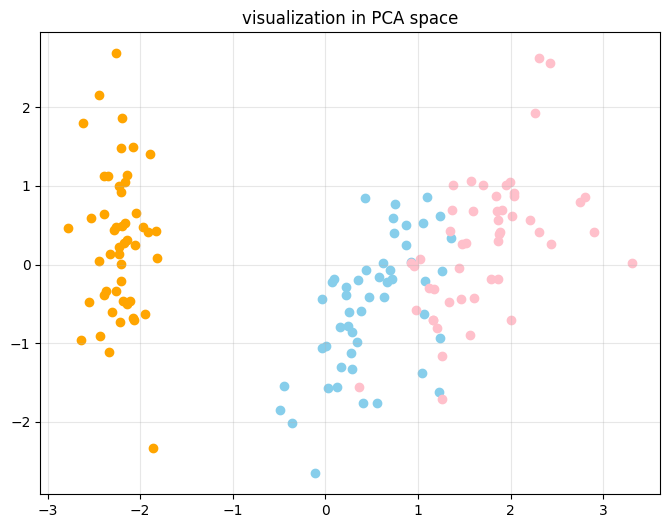

In [15]:
# PCA 공간에서 시각화
plt.figure(figsize=(8,6))
color = ['orange','skyblue','pink']

for i in range(3):
    mask = iris.target == i
    plt.scatter(X_pca[mask, 0], X_pca[mask,1], c=color[i])
    plt.title('visualization in PCA space') 
    plt.grid(True, alpha=0.3) 

과제 2: K-Means 최적 K 찾기
Elbow Method와 Silhouette Score 사용 → 최적 K 선택 및 결과 비교

In [26]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

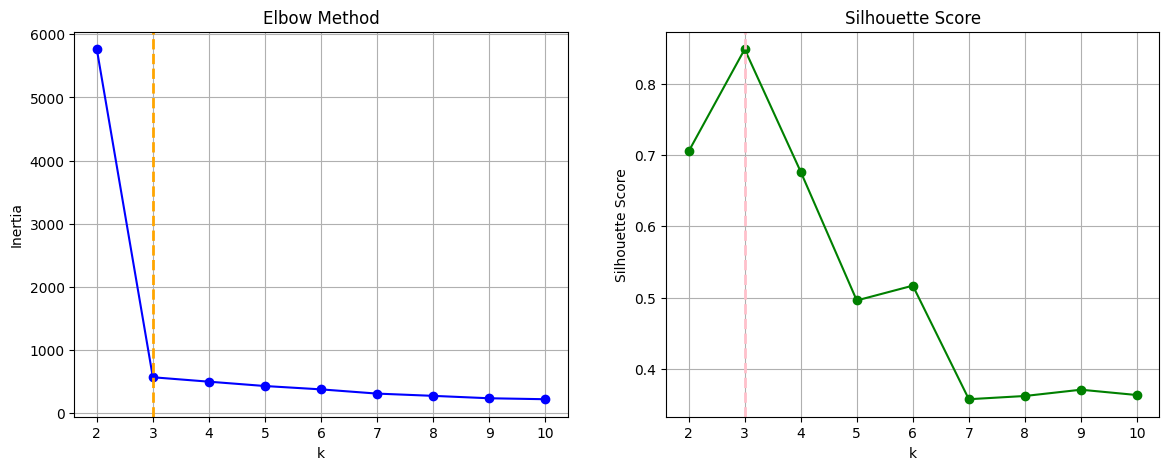

In [36]:
# 그래프로 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=3, linestyle='--', linewidth=2, color = "orange")
axes[0].grid(True)

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(x=3, linestyle='--', linewidth=2, color = "pink")
axes[1].grid(True)

과제 3: 알고리즘 비교
같은 데이터로 K-Means와 Hierarchical 실행 → 결과와 성능 비교 분석 
덴드로그램을 그려서 수평선을 그었을때 군집이 몇개가 나오는지 N = 5 ,3으로 했을 때 평가가 높은ㅈㅣ

In [37]:
# 데이터 생성
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

3

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_20863/29340653.py:8: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(kmeans.cluster_centers_[:, 0],


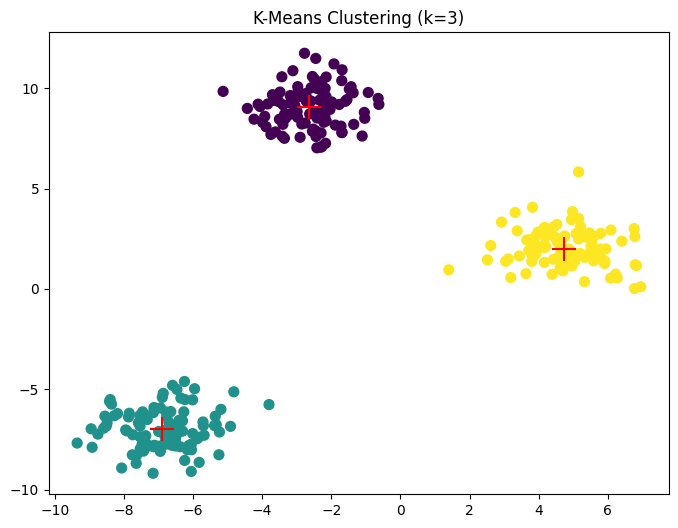

In [53]:
# K-Means  
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X) 

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x=X[:, 0], y=X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1],
           c='red', s=300, marker='+', edgecolors='black')
plt.title('K-Means Clustering (k=3)')
plt.show()

In [54]:
print(f"성능비교 : {silhouette_score(X, labels)}")

성능비교 : 0.8480303059596955


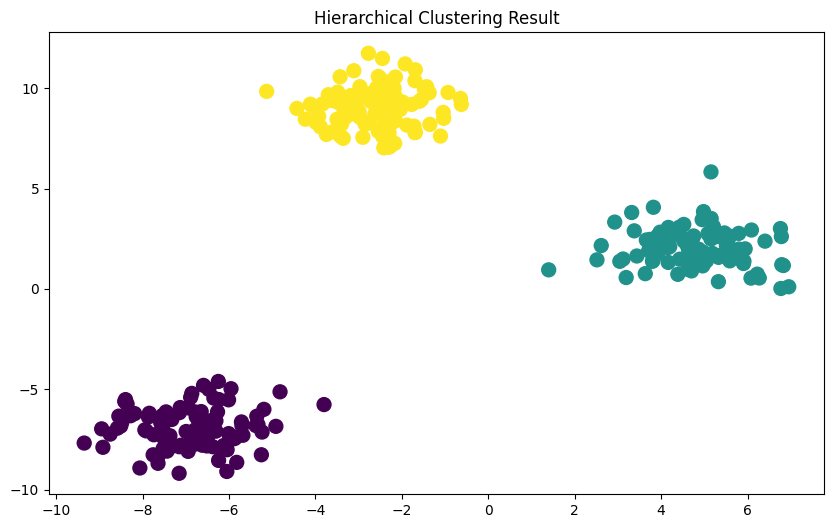

In [55]:
# Hierarchical Clustering 
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = clustering.fit_predict(X)

# 시각화
plt.figure(figsize=(10, 6)) 
plt.scatter(X[:, 0], X[:, 1], c=labels, s=100, cmap='viridis') 
plt.title('Hierarchical Clustering Result') 
plt.show()

In [56]:
print(f"성능비교 : {silhouette_score(X, labels)}")

성능비교 : 0.8480303059596955


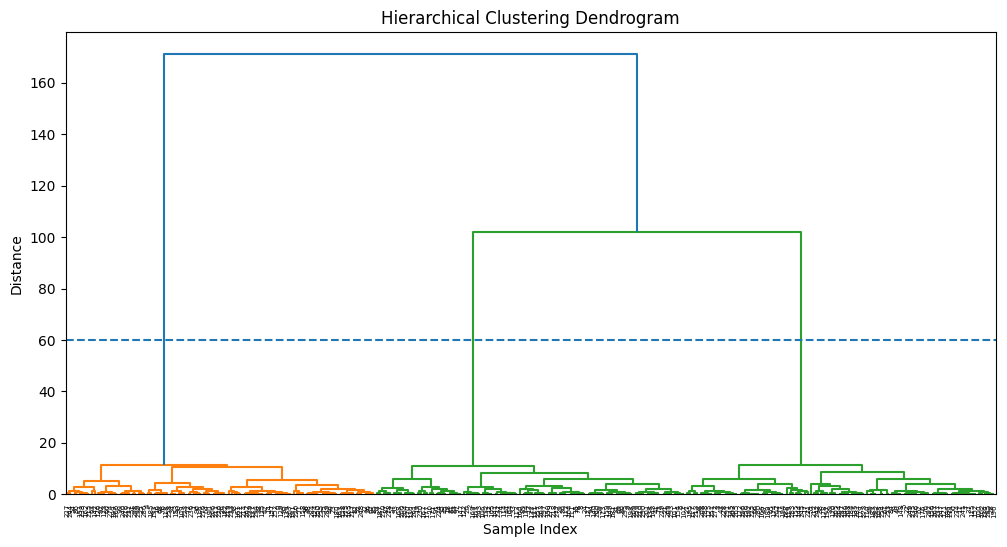

In [57]:
#  Dendrogram 그리기
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.axhline(y=60, linestyle='--', linewidth=1.5) 
plt.show()

5

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_20863/2084091911.py:8: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(kmeans.cluster_centers_[:, 0],


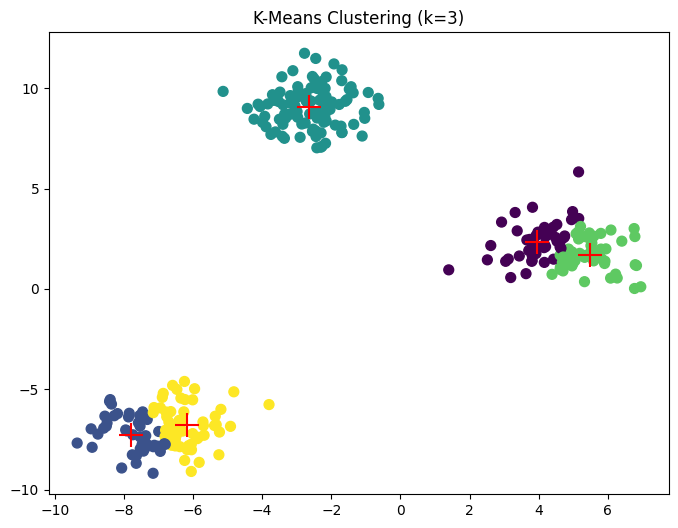

In [58]:
# K-Means  
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X) 

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x=X[:, 0], y=X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1],
           c='red', s=300, marker='+', edgecolors='black')
plt.title('K-Means Clustering (k=3)')
plt.show()

In [59]:
print(f"성능비교 : {silhouette_score(X, labels)}")

성능비교 : 0.49012744554094306


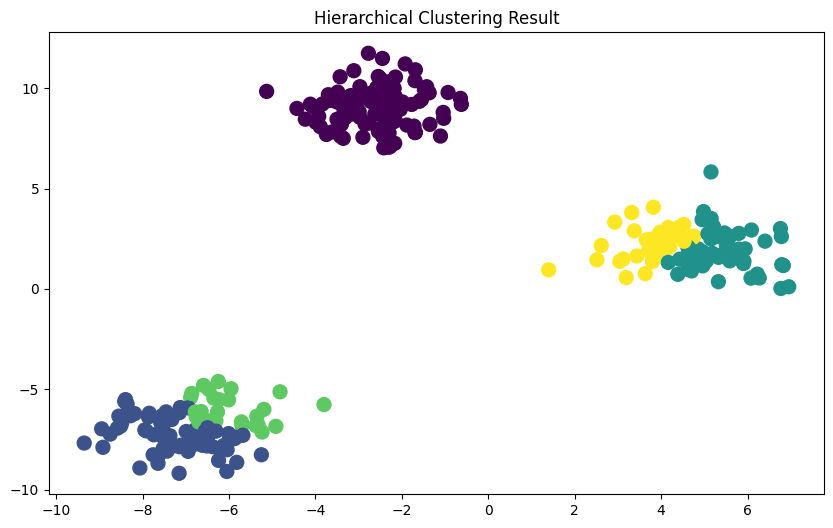

In [60]:
# Hierarchical Clustering 
clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = clustering.fit_predict(X)

# 시각화
plt.figure(figsize=(10, 6)) 
plt.scatter(X[:, 0], X[:, 1], c=labels, s=100, cmap='viridis') 
plt.title('Hierarchical Clustering Result') 
plt.show()

In [61]:
print(f"성능비교 : {silhouette_score(X, labels)}")

성능비교 : 0.4892559100691162
